In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import LabelEncoder

In [18]:
df=pd.read_csv("Social_Network_Ads.csv")

In [19]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   User ID          400 non-null    int64  
 1   Gender           400 non-null    object 
 2   Age              400 non-null    float64
 3   EstimatedSalary  400 non-null    float64
 4   Purchased        400 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 15.8+ KB


In [41]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19.0,19000.0,0
1,15810944,1,35.0,20000.0,0
2,15668575,0,26.0,43000.0,0
3,15603246,0,27.0,57000.0,0
4,15804002,1,19.0,76000.0,0
...,...,...,...,...,...
395,15691863,0,46.0,41000.0,1
396,15706071,1,51.0,23000.0,1
397,15654296,0,50.0,20000.0,1
398,15755018,1,36.0,33000.0,0


In [21]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [40]:
df['Purchased']

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

In [16]:
df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

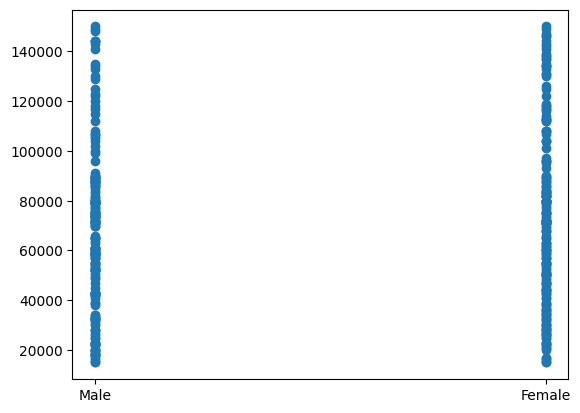

In [25]:
plt.scatter(df['Gender'],df['EstimatedSalary'])
plt.show()

In [28]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [29]:
df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [33]:
x=df[['Gender', 'Age', 'EstimatedSalary']]
y=df[ 'Purchased']

In [34]:
x_train,x_test,y_train,y_test =train_test_split(x,y,test_size=0.2,random_state=0)

In [48]:
from sklearn.linear_model import LogisticRegression
# instantiate the model (using the default parameters)
logreg = LogisticRegression(max_iter=400)
logreg.fit(x_train, y_train)

LogisticRegression(max_iter=400)

In [49]:
y_pred = logreg.predict(x_test)

print(y_pred)

[0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0
 0 0 1 0 1 1]


In [50]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [51]:
print(f"accuracy={accuracy_score(y_test,y_pred)}")

accuracy=0.925


In [53]:
print(f"confusion matrix=\n{confusion_matrix(y_test,y_pred)}")

confusion matrix=
[[56  2]
 [ 4 18]]


In [54]:
df.groupby('Gender')['Purchased'].sum()

Gender
0    77
1    66
Name: Purchased, dtype: int64